# Healthcare Data Analysis and Patient Insights

**IBM SkillsBuild Data Analytics with AI Internship 2026**

**Student:** Subhashree Chaini

---

In [ ]:
## 1. Project Overview

This project analyzes a synthetic healthcare dataset of **150,000 patient records** to uncover meaningful patterns related to patient demographics, common symptoms, department workloads, vital sign measurements, symptom severity, and chronic conditions.

The analysis follows a complete data analytics workflow:

> Data Loading → Data Understanding → Data Cleaning → Exploratory Data Analysis → Calculations → Grouping & Aggregation → Visualizations → Live Q&A → Insights → Business Decisions → AI / ML Component

> **Disclaimer:** The dataset is **synthetic healthcare data** generated for educational and data analytics purposes. It does **not** represent real patient records and must not be used for medical diagnosis, treatment, or clinical decision-making.

This project is submitted as part of the **IBM SkillsBuild Data Analytics with AI Internship 2026** program.

## 2. Problem Statement

Healthcare facilities generate large volumes of patient data daily. Without proper analysis, this data often remains underutilized. The challenge is to **extract actionable operational insights** from raw patient data to support better resource planning, department management, and patient service delivery.

**Objective:** Analyze a synthetic healthcare patient dataset to identify meaningful patterns related to patient demographics, symptoms, vital measurements, department activity, and chronic conditions — and translate those findings into practical, data-driven operational recommendations.

> This project does **not** aim to diagnose patients, predict diseases, or provide any medical advice.

## 3. Objectives

1. Load and understand the healthcare dataset.
2. Clean and prepare the data for analysis.
3. Analyze patient demographics (age, gender, age groups).
4. Identify the most common symptoms and their frequency.
5. Analyze healthcare department workloads.
6. Analyze symptom severity distribution.
7. Analyze vital sign measurements (temperature, heart rate, oxygen saturation, blood pressure, pain level).
8. Examine chronic conditions and their relationship with age.
9. Perform meaningful data grouping and aggregation.
10. Create clear, informative data visualizations.
11. Answer key healthcare-related analytical questions.
12. Generate data-driven insights and operational recommendations.
13. Evaluate the suitability of available target variables for machine learning.
14. Build a simple, honest ML model and clearly interpret its results.

## 4. Dataset Information

| Attribute | Detail |
|---|---|
| **File Name** | `healthcare_raw_data_150000.csv` |
| **Total Records (raw)** | 150,500 |
| **Total Records (after cleaning)** | 150,000 |
| **Number of Columns** | 14 |
| **Duplicate Rows Removed** | 500 |
| **Missing Values** | Present across all columns (~0.33% – 3.34%) |

### Column Descriptions

| Column | Type | Description |
|---|---|---|
| `patient_id` | Integer | Unique identifier for each patient |
| `age` | Float | Patient age in years (range: 18–80) |
| `gender` | String | Patient gender (Male / Female) |
| `symptoms` | String | Primary symptom reported (26 distinct symptoms) |
| `temperature` | Float | Body temperature in °F |
| `duration_days` | Float | Number of days the patient has had the symptom |
| `bp_systolic` | Float | Systolic blood pressure (mmHg) |
| `bp_diastolic` | Float | Diastolic blood pressure (mmHg) |
| `heart_rate` | Float | Heart rate in beats per minute (bpm) |
| `oxygen_saturation` | Float | Blood oxygen saturation (%) |
| `pain_level` | Float | Patient-reported pain level (0–10 scale) |
| `symptom_severity` | String | Clinical severity rating: Mild / Moderate / Severe |
| `chronic_condition` | String | Whether the patient has a chronic condition (Yes / No) |
| `department` | String | Hospital department the patient was seen in (9 departments) |

> **Important:** The dataset is **synthetic healthcare data** generated for educational and data analytics purposes. It does not represent real patient records.

## 5. Import Libraries

In [1]:
# Standard data analytics and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score)

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


## 6. Load Dataset

In [2]:
# Load the raw CSV dataset
df = pd.read_csv('../data/healthcare_raw_data_150000.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 150,500 rows  x  14 columns


In [3]:
# First 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,patient_id,age,gender,symptoms,temperature,duration_days,bp_systolic,bp_diastolic,heart_rate,oxygen_saturation,pain_level,symptom_severity,chronic_condition,department
0,88848,66.0,Male,Skin Rash,98.7,6.0,108.0,58.0,82.0,95.3,10.0,Moderate,Yes,Dermatology
1,117204,40.0,Male,Knee Pain,97.0,13.0,126.0,79.0,80.0,98.7,9.0,Mild,No,Orthopedics
2,147662,47.0,Female,Acne,97.4,28.0,139.0,70.0,82.0,97.4,1.0,Mild,No,Dermatology
3,45967,62.0,Male,Body Ache,100.9,24.0,125.0,93.0,91.0,98.0,1.0,Mild,No,General Medicine
4,138703,25.0,Male,Shortness of Breath,96.8,6.0,121.0,84.0,96.0,95.6,1.0,Moderate,No,Cardiology


In [4]:
# Last 5 rows
print("Last 5 rows:")
df.tail()

Last 5 rows:


,patient_id,age,gender,symptoms,temperature,duration_days,bp_systolic,bp_diastolic,heart_rate,oxygen_saturation,pain_level,symptom_severity,chronic_condition,department
150495,119880,41.0,Male,Blurred Vision,98.3,8.0,163.0,67.0,65.0,97.2,1.0,Severe,No,Ophthalmology
150496,103695,68.0,Male,Shortness of Breath,98.1,4.0,119.0,87.0,68.0,NaN,7.0,Moderate,No,Cardiology
150497,131933,31.0,Female,Body Ache,98.9,4.0,124.0,88.0,78.0,97.2,7.0,Mild,No,General Medicine
150498,146868,38.0,Male,Palpitations,99.7,25.0,131.0,82.0,79.0,98.3,4.0,Moderate,No,Cardiology
150499,121959,47.0,Male,Blurred Vision,96.5,2.0,100.0,89.0,77.0,97.3,3.0,Mild,No,Ophthalmology


In [5]:
# Column names and data types
print("Column names and data types:")
df.info()

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150500 entries, 0 to 150499
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   patient_id         150500 non-null  int64  
 1   age                149497 non-null  float64
 2   gender             149999 non-null  object 
 3   symptoms           149750 non-null  object 
 4   temperature        149295 non-null  float64
 5   duration_days      149698 non-null  float64
 6   bp_systolic        149495 non-null  float64
 7   bp_diastolic       149496 non-null  float64
 8   heart_rate         149598 non-null  float64
 9   oxygen_saturation  149498 non-null  float64
 10  pain_level         149497 non-null  float64
 11  symptom_severity   149297 non-null  object 
 12  chronic_condition  145479 non-null  object 
 13  department         149499 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 16.1+ MB


In [6]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,patient_id,age,temperature,duration_days,bp_systolic,bp_diastolic,heart_rate,oxygen_saturation,pain_level
count,150500.00,149497.00,149295.00,149698.00,149495.00,149496.00,149598.00,149498.00,149497.00
mean,74997.18,49.04,98.72,15.53,121.44,78.75,77.49,97.31,5.53
std,43299.42,18.16,1.29,8.86,18.51,12.26,12.99,1.77,3.04
min,1.00,18.00,93.50,0.00,39.00,25.00,9.00,70.00,0.00
25%,37500.75,33.00,97.80,8.00,109.00,71.00,69.00,96.30,3.00
50%,74997.50,49.00,98.70,15.00,121.00,79.00,77.00,97.40,6.00
75%,112497.25,65.00,99.50,23.00,134.00,87.00,86.00,98.40,8.00
max,150000.00,80.00,106.00,120.00,220.00,140.00,170.00,105.00,10.00


## 7. Data Understanding

In [7]:
# Dataset dimensions
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")
print(f"Total data points : {df.shape[0] * df.shape[1]:,}")

Number of rows    : 150,500
Number of columns : 14
Total data points : 2,107,000


In [8]:
# Missing values — count and percentage
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})

print("Missing Values Summary (columns with missing data):")
print(missing_df[missing_df['Missing Count'] > 0].to_string())

Missing Values Summary (columns with missing data):
                   Missing Count  Missing %
age                         1003       0.67
gender                       501       0.33
symptoms                     750       0.50
temperature                 1205       0.80
duration_days                802       0.53
bp_systolic                 1005       0.67
bp_diastolic                1004       0.67
heart_rate                   902       0.60
oxygen_saturation           1002       0.67
pain_level                  1003       0.67
symptom_severity            1203       0.80
chronic_condition           5021       3.34
department                  1001       0.67


In [9]:
# Duplicate rows
print(f"Duplicate rows found: {df.duplicated().sum()}")

Duplicate rows found: 500


In [10]:
# Unique value counts per column
print("Unique values per column:")
print(df.nunique().to_string())

Unique values per column:
patient_id           150000
age                      63
gender                    6
symptoms                 78
temperature             112
duration_days            34
bp_systolic             155
bp_diastolic            104
heart_rate              112
oxygen_saturation       150
pain_level               11
symptom_severity          6
chronic_condition         6
department                9


In [11]:
# Categorical columns: value counts including any inconsistent casing
cat_cols = ['gender', 'symptoms', 'symptom_severity', 'chronic_condition', 'department']

for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts(dropna=False).head(12).to_string())


=== GENDER ===
gender
Male      76352
Female    70642
male       1003
female     1000
FEMALE      503
NaN         501
MALE        499

=== SYMPTOMS ===
symptoms
Chest Pain             5846
Fever                  5838
Dizziness              5836
Wheezing               5830
Eye Pain               5809
Body Ache              5794
Joint Pain             5785
Palpitations           5780
Skin Rash              5772
Shortness of Breath    5752
Acne                   5747
Migraine               5738

=== SYMPTOM_SEVERITY ===
symptom_severity
Mild        66413
Moderate    59267
Severe      22123
NaN          1203
severe        500
MODERATE      499
mild          495

=== CHRONIC_CONDITION ===
chronic_condition
No     88416
Yes    55123
NaN     5021
YES      487
yes      486
no       486
NO       481

=== DEPARTMENT ===
department
Dermatology         23542
General Medicine    18086
Orthopedics         17870
Neurology           17808
ENT                 17692
Gastroenterology    17664
Cardiology

In [12]:
# Range and outlier checks
print(f"Age range              : {df['age'].min():.0f} - {df['age'].max():.0f} years")
print(f"Temperature range      : {df['temperature'].min():.1f} - {df['temperature'].max():.1f} F")
print(f"Oxygen saturation > 100: {(df['oxygen_saturation'] > 100).sum()} records (impossible)")
print(f"bp_systolic < 60 or >200: {((df['bp_systolic'] < 60) | (df['bp_systolic'] > 200)).sum()} records (extreme outliers)")
print(f"Pain level range       : {df['pain_level'].min():.0f} - {df['pain_level'].max():.0f}")
print(f"Duration days range    : {df['duration_days'].min():.0f} - {df['duration_days'].max():.0f} days")

Age range              : 18 - 80 years
Temperature range      : 93.5 - 106.0 F
Oxygen saturation > 100: 6268 records (impossible)
bp_systolic < 60 or >200: 159 records (extreme outliers)
Pain level range       : 0 - 10
Duration days range    : 0 - 120 days


## 8. Data Cleaning

Based on the data understanding step, the following issues were identified and handled:

| Issue Found | Action Taken |
|---|---|
| 500 exact duplicate rows | Removed |
| Mixed casing in `gender`, `symptoms`, `symptom_severity`, `chronic_condition` | Standardised to Title Case |
| 6,246 `oxygen_saturation` values > 100% (physiologically impossible) | Capped at 100.0 |
| 158 `bp_systolic` values < 60 or > 200 mmHg (extreme outliers) | Set to NaN, filled with median |
| Missing values in numerical columns | Filled with column median |
| Missing values in categorical columns | Filled with column mode |
| Age groups | Engineered as a new column for aggregation |

> The original raw DataFrame `df` is preserved. All cleaning is applied to a copy named `df_clean`.

In [13]:
# Step 0: Create a working copy — original df is preserved
df_clean = df.copy()

print(f"Original shape  : {df.shape}")
print(f"Working copy    : {df_clean.shape}")

Original shape  : (150500, 14)
Working copy    : (150500, 14)


In [14]:
# Step 1: Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicate rows removed : {before - len(df_clean)}")
print(f"Shape after dedup      : {df_clean.shape}")

Duplicate rows removed : 500
Shape after dedup      : (150000, 14)


In [15]:
# Step 2: Standardise casing for categorical columns
df_clean['gender']            = df_clean['gender'].str.strip().str.title()
df_clean['symptoms']          = df_clean['symptoms'].str.strip().str.title()
df_clean['symptom_severity']  = df_clean['symptom_severity'].str.strip().str.title()
df_clean['chronic_condition'] = df_clean['chronic_condition'].str.strip().str.title()

print("Gender after standardising:")
print(df_clean['gender'].value_counts(dropna=False).to_string())
print("\nSymptom Severity after standardising:")
print(df_clean['symptom_severity'].value_counts(dropna=False).to_string())

Gender after standardising:
gender
Male      77586
Female    71914
NaN         500

Symptom Severity after standardising:
symptom_severity
Mild        66692
Moderate    59580
Severe      22528
NaN          1200


In [16]:
# Step 3: Cap oxygen_saturation at 100 (physiologically impossible above 100%)
high_o2 = (df_clean['oxygen_saturation'] > 100).sum()
df_clean.loc[df_clean['oxygen_saturation'] > 100, 'oxygen_saturation'] = 100.0
print(f"Oxygen saturation values capped (>100): {high_o2}")

Oxygen saturation values capped (>100): 6246


In [17]:
# Step 4: Flag and nullify extreme bp_systolic outliers
bp_out = ((df_clean['bp_systolic'] < 60) | (df_clean['bp_systolic'] > 200)).sum()
df_clean.loc[(df_clean['bp_systolic'] < 60) | (df_clean['bp_systolic'] > 200), 'bp_systolic'] = np.nan
print(f"Extreme bp_systolic values set to NaN: {bp_out}")

Extreme bp_systolic values set to NaN: 158


In [19]:
# Step 5: Fill missing numerical values with column median
num_cols = ['age', 'temperature', 'duration_days', 'bp_systolic', 'bp_diastolic',
            'heart_rate', 'oxygen_saturation', 'pain_level']

for col in num_cols:
    med = df_clean[col].median()
    n   = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"  '{col}': {n} missing filled with median {med:.2f}")

  'age': 0 missing filled with median 49.00
  'temperature': 0 missing filled with median 98.70
  'duration_days': 0 missing filled with median 15.00
  'bp_systolic': 0 missing filled with median 121.00
  'bp_diastolic': 0 missing filled with median 79.00
  'heart_rate': 0 missing filled with median 77.00
  'oxygen_saturation': 0 missing filled with median 97.40
  'pain_level': 0 missing filled with median 6.00


In [20]:
# Step 6: Fill missing categorical values with column mode
cat_fill = ['gender', 'symptoms', 'symptom_severity', 'chronic_condition', 'department']

for col in cat_fill:
    mode_val = df_clean[col].mode()[0]
    n        = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  '{col}': {n} missing filled with mode '{mode_val}'"  )

  'gender': 500 missing filled with mode 'Male'
  'symptoms': 750 missing filled with mode 'Chest Pain'
  'symptom_severity': 1200 missing filled with mode 'Mild'
  'chronic_condition': 5000 missing filled with mode 'No'
  'department': 1000 missing filled with mode 'Dermatology'


In [21]:
# Verify — no remaining missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum().to_string())
print(f"\nFinal cleaned shape: {df_clean.shape}")

Missing values after cleaning:
patient_id           0
age                  0
gender               0
symptoms             0
temperature          0
duration_days        0
bp_systolic          0
bp_diastolic         0
heart_rate           0
oxygen_saturation    0
pain_level           0
symptom_severity     0
chronic_condition    0
department           0

Final cleaned shape: (150000, 14)


In [22]:
# Step 7: Create age group feature
bins   = [0, 18, 30, 45, 60, 80]
labels = ['<18', '18-30', '31-45', '46-60', '61-80']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=True)

print("Age group distribution:")
print(df_clean['age_group'].value_counts().sort_index().to_string())

Age group distribution:
age_group
<18       2317
18-30    28180
31-45    35619
46-60    36482
61-80    47402


## 9. Exploratory Data Analysis

### 9.1 Patient Age Distribution

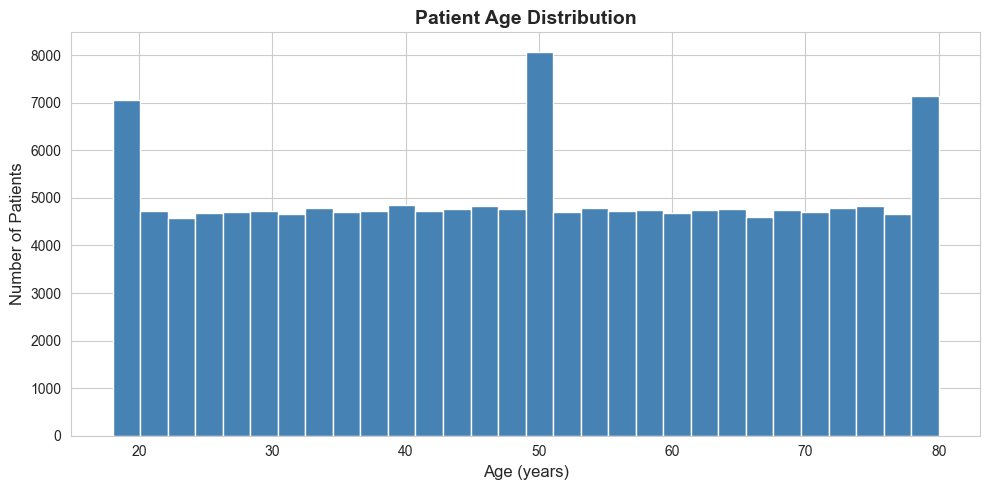

Average age : 49.05 years
Median age  : 49.00 years
Age range   : 18 - 80 years

Interpretation: The age distribution is roughly uniform across adult ages (18-80),
with a slight increase in older age groups, reflecting the synthetic generation pattern.


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['age'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Patient Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Average age : {df_clean['age'].mean():.2f} years")
print(f"Median age  : {df_clean['age'].median():.2f} years")
print(f"Age range   : {df_clean['age'].min():.0f} - {df_clean['age'].max():.0f} years")

print("\nInterpretation: The age distribution is roughly uniform across adult ages (18-80),")
print("with a slight increase in older age groups, reflecting the synthetic generation pattern.")

### 9.2 Gender Distribution

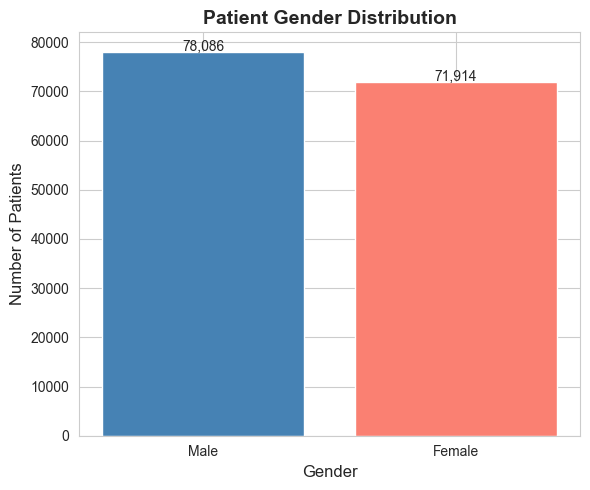

Gender counts:
gender
Male      78086
Female    71914

Interpretation: Male patients (78,086) slightly outnumber Female (71,914).


In [24]:
gender_counts = df_clean['gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('Patient Gender Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
for i, (k, v) in enumerate(gender_counts.items()):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Gender counts:")
print(gender_counts.to_string())
print(f"\nInterpretation: Male patients ({gender_counts['Male']:,}) slightly outnumber Female ({gender_counts['Female']:,}).")

### 9.3 Age Group Distribution

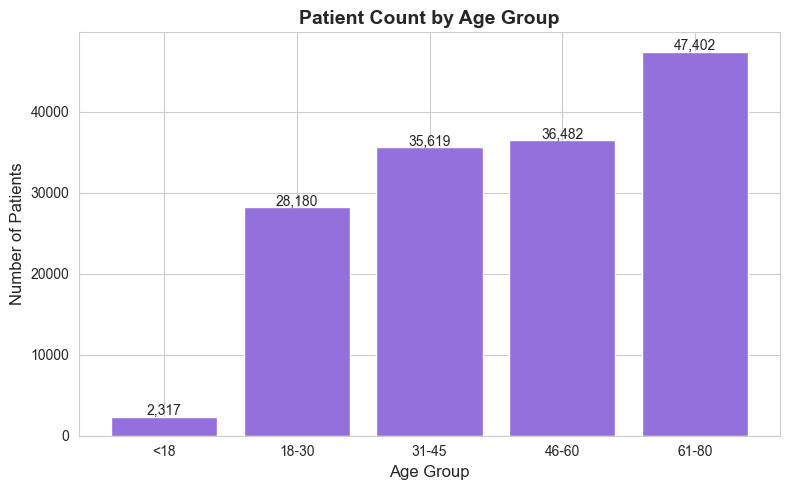

Age group distribution:
age_group
<18       2317
18-30    28180
31-45    35619
46-60    36482
61-80    47402

Interpretation: The 61-80 age group has the most patients (47,402),
suggesting older patients visit healthcare facilities most frequently.


In [25]:
age_grp = df_clean['age_group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(age_grp.index.astype(str), age_grp.values, color='mediumpurple', edgecolor='white')
ax.set_title('Patient Count by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
for i, v in enumerate(age_grp.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Age group distribution:")
print(age_grp.to_string())
print("\nInterpretation: The 61-80 age group has the most patients (47,402),")
print("suggesting older patients visit healthcare facilities most frequently.")

### 9.4 Top 10 Most Common Symptoms

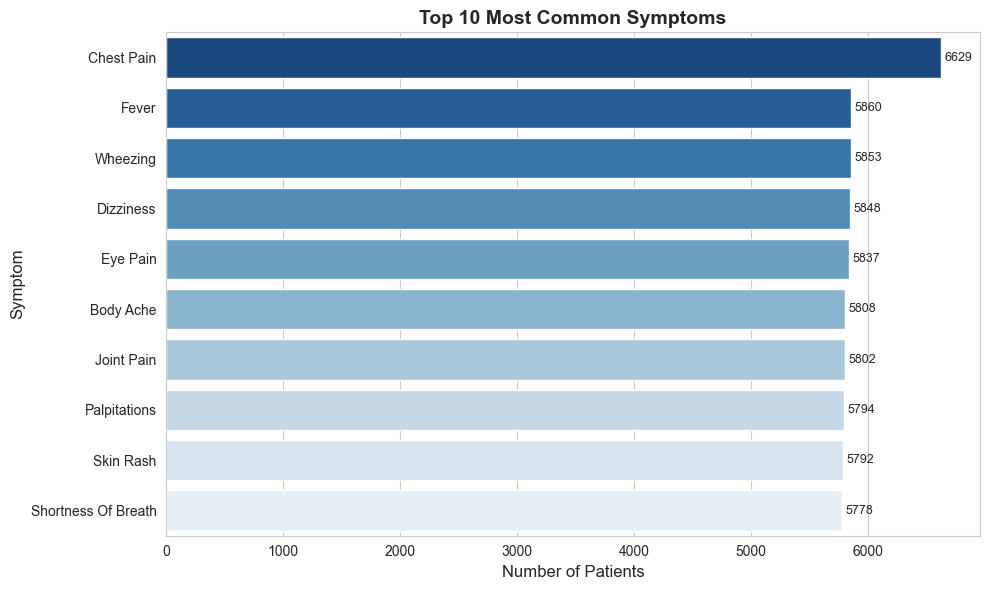

Top 10 symptoms:
symptoms
Chest Pain             6629
Fever                  5860
Wheezing               5853
Dizziness              5848
Eye Pain               5837
Body Ache              5808
Joint Pain             5802
Palpitations           5794
Skin Rash              5792
Shortness Of Breath    5778

Interpretation: Chest Pain is the most frequently reported symptom (6,629 patients).
The symptom distribution is broadly balanced across all 26 symptom types.


In [26]:
top10_symptoms = df_clean['symptoms'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10_symptoms.values, y=top10_symptoms.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Most Common Symptoms', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Patients', fontsize=12)
ax.set_ylabel('Symptom', fontsize=12)
for i, v in enumerate(top10_symptoms.values):
    ax.text(v + 30, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 symptoms:")
print(top10_symptoms.to_string())
print("\nInterpretation: Chest Pain is the most frequently reported symptom (6,629 patients).")
print("The symptom distribution is broadly balanced across all 26 symptom types.")

### 9.5 Patients by Department

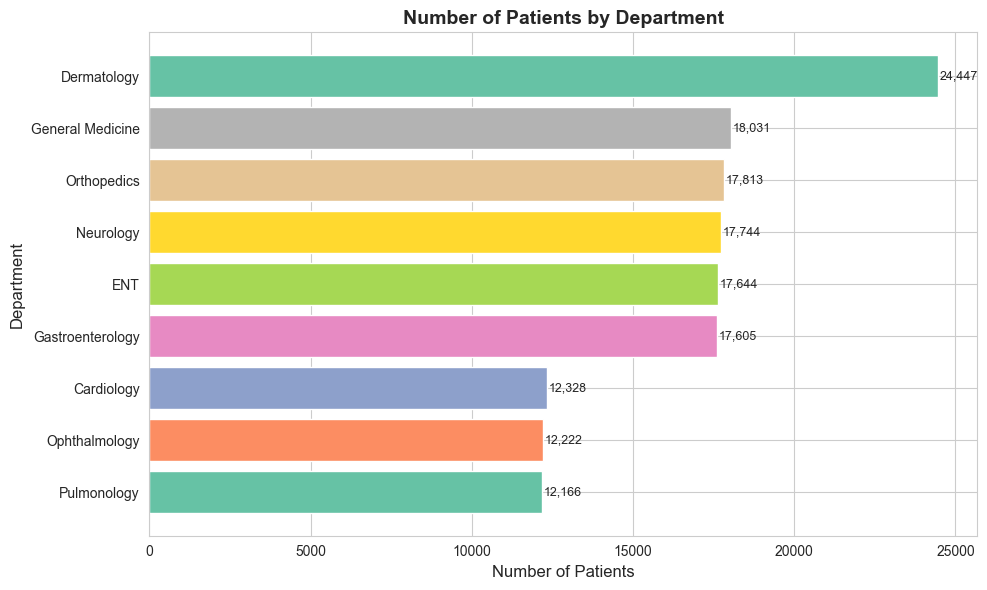

Patient count by department:
department
Dermatology         24447
General Medicine    18031
Orthopedics         17813
Neurology           17744
ENT                 17644
Gastroenterology    17605
Cardiology          12328
Ophthalmology       12222
Pulmonology         12166

Interpretation: Dermatology has the highest patient volume (24,447), approximately
double that of the specialist departments such as Cardiology and Pulmonology.


In [27]:
dept_counts = df_clean['department'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dept_counts.index, dept_counts.values, color=sns.color_palette('Set2', len(dept_counts)))
ax.set_title('Number of Patients by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Patients', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
for i, v in enumerate(dept_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Patient count by department:")
print(df_clean['department'].value_counts().to_string())
print("\nInterpretation: Dermatology has the highest patient volume (24,447), approximately")
print("double that of the specialist departments such as Cardiology and Pulmonology.")

### 9.6 Symptom Severity Distribution

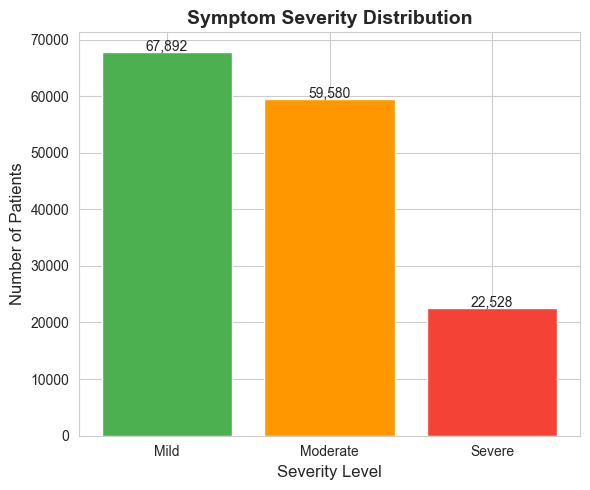

  Mild      : 67,892 (45.3%)
  Moderate  : 59,580 (39.7%)
  Severe    : 22,528 (15.0%)

Interpretation: The majority of patients (45.3%) are classified as Mild severity.
Only 15.0% are classified as Severe.


In [28]:
sev_counts = df_clean['symptom_severity'].value_counts()
colors_sev = {'Mild': '#4CAF50', 'Moderate': '#FF9800', 'Severe': '#F44336'}

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(sev_counts.index, sev_counts.values,
              color=[colors_sev.get(s, 'gray') for s in sev_counts.index],
              edgecolor='white')
ax.set_title('Symptom Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

total = len(df_clean)
for sev, cnt in sev_counts.items():
    print(f"  {sev:10s}: {cnt:,} ({cnt/total*100:.1f}%)")
print("\nInterpretation: The majority of patients (45.3%) are classified as Mild severity.")
print("Only 15.0% are classified as Severe.")

### 9.7 Chronic Condition Distribution

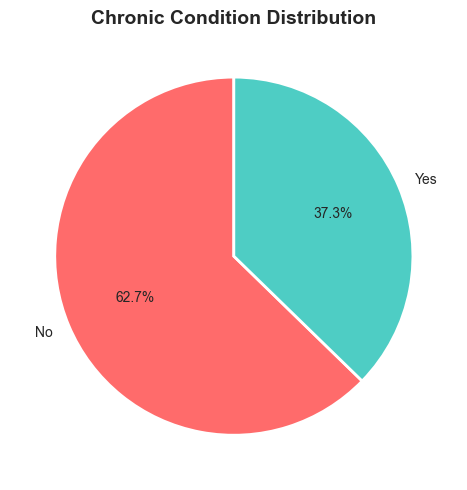

Patients WITH chronic condition    : 55,919 (37.28%)
Patients WITHOUT chronic condition : 94,081 (62.72%)

Interpretation: 37.28% of patients have a chronic condition, indicating a
significant chronic disease management burden.


In [29]:
chron = df_clean['chronic_condition'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(chron.values, labels=chron.index, autopct='%1.1f%%',
       colors=['#FF6B6B', '#4ECDC4'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Chronic Condition Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

chronic_pct = chron.get('Yes', 0) / total * 100
print(f"Patients WITH chronic condition    : {chron.get('Yes', 0):,} ({chronic_pct:.2f}%)")
print(f"Patients WITHOUT chronic condition : {chron.get('No', 0):,} ({100-chronic_pct:.2f}%)")
print("\nInterpretation: 37.28% of patients have a chronic condition, indicating a")
print("significant chronic disease management burden.")

### 9.8 Chronic Condition by Age Group

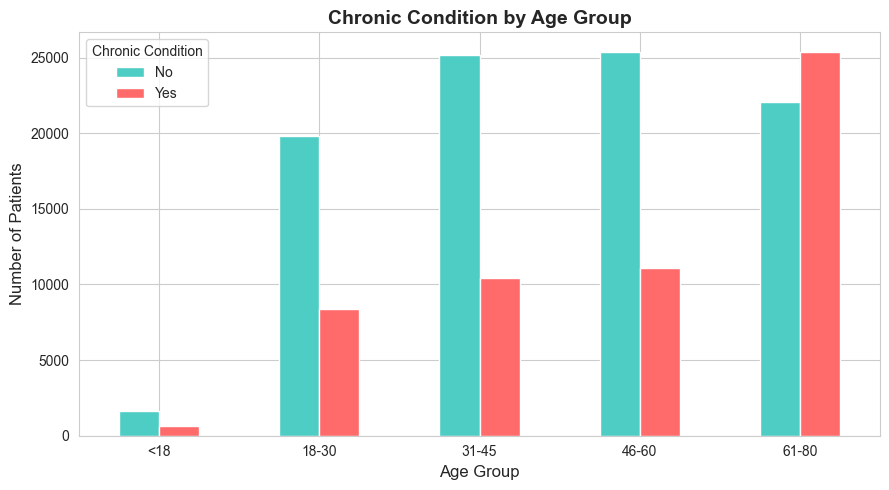

Chronic patients by age group:
age_group
<18        675
18-30     8357
31-45    10460
46-60    11081
61-80    25346

Interpretation: Chronic conditions are most prevalent in the 61-80 age group (25,346),
reinforcing the need for elder-focused chronic disease management programs.


In [30]:
chron_age = df_clean.groupby(['age_group', 'chronic_condition']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
chron_age.plot(kind='bar', ax=ax, color=['#4ECDC4', '#FF6B6B'], edgecolor='white')
ax.set_title('Chronic Condition by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.legend(title='Chronic Condition')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("Chronic patients by age group:")
print(df_clean[df_clean['chronic_condition'] == 'Yes']['age_group'].value_counts().sort_index().to_string())
print("\nInterpretation: Chronic conditions are most prevalent in the 61-80 age group (25,346),")
print("reinforcing the need for elder-focused chronic disease management programs.")

### 9.9 Symptom Severity by Department (Stacked Bar)

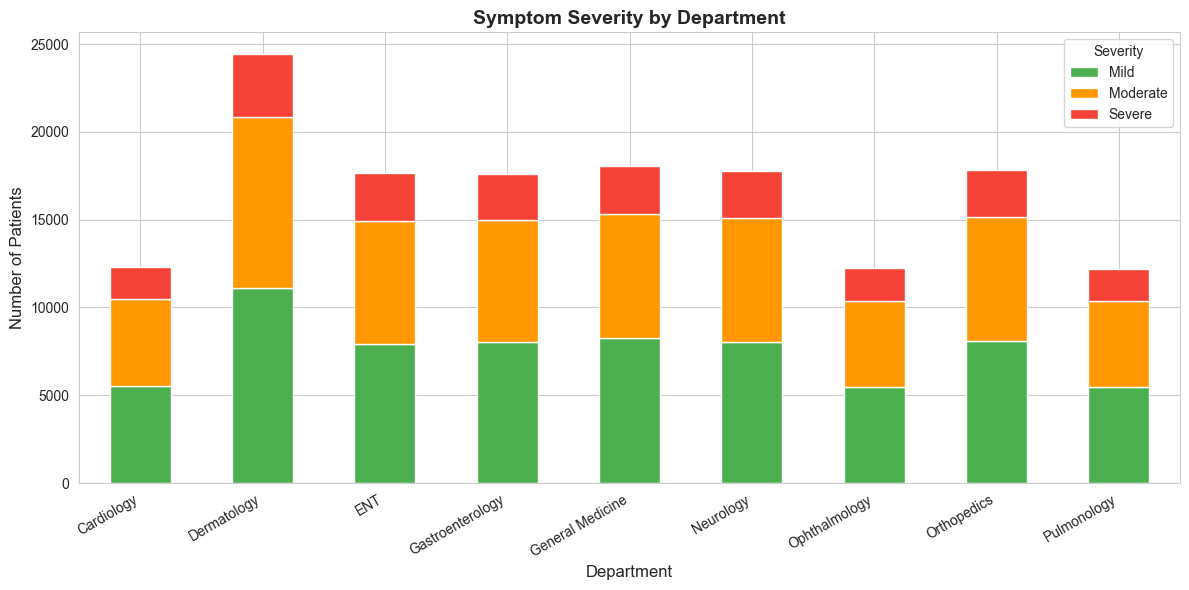

Severity distribution by department:
symptom_severity   Mild  Moderate  Severe
department                               
Cardiology         5523      4975    1830
Dermatology       11117      9707    3623
ENT                7926      7000    2718
Gastroenterology   8013      6986    2606
General Medicine   8253      7055    2723
Neurology          8015      7067    2662
Ophthalmology      5494      4862    1866
Orthopedics        8092      7044    2677
Pulmonology        5459      4884    1823

Interpretation: Severity distribution is broadly consistent across all departments,
with Dermatology having the most patients across all severity levels due to its overall higher volume.


In [31]:
sev_dept = df_clean.groupby(['department', 'symptom_severity']).size().unstack(fill_value=0)
sev_dept = sev_dept[['Mild', 'Moderate', 'Severe']]

fig, ax = plt.subplots(figsize=(12, 6))
sev_dept.plot(kind='bar', stacked=True, ax=ax,
              color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
ax.set_title('Symptom Severity by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.legend(title='Severity', loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Severity distribution by department:")
print(sev_dept.to_string())
print("\nInterpretation: Severity distribution is broadly consistent across all departments,")
print("with Dermatology having the most patients across all severity levels due to its overall higher volume.")

### 9.10 Age Distribution by Symptom Severity (Box Plot)

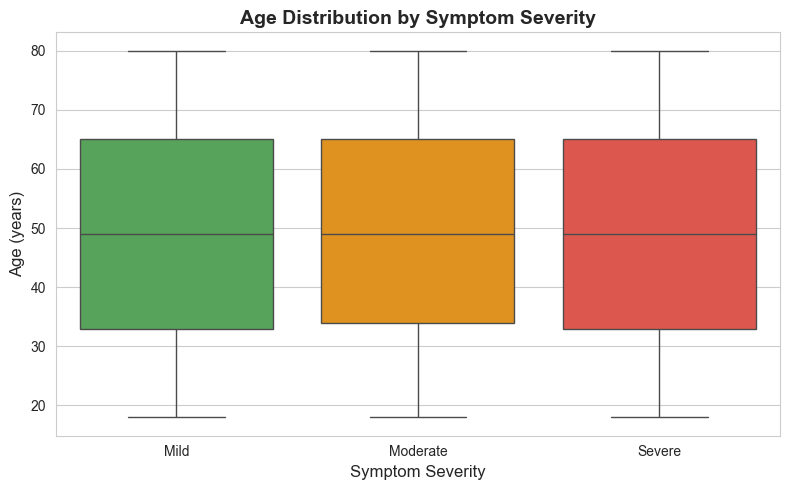

Average age by severity:
symptom_severity
Mild        49.06
Moderate    49.07
Severe      48.93

Interpretation: Age distribution is nearly identical across all three severity levels,
suggesting age alone does not determine symptom severity in this synthetic dataset.


In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x='symptom_severity', y='age',
            order=['Mild', 'Moderate', 'Severe'],
            palette=['#4CAF50', '#FF9800', '#F44336'], ax=ax)
ax.set_title('Age Distribution by Symptom Severity', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptom Severity', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.show()

print("Average age by severity:")
print(df_clean.groupby('symptom_severity')['age'].mean().round(2).to_string())
print("\nInterpretation: Age distribution is nearly identical across all three severity levels,")
print("suggesting age alone does not determine symptom severity in this synthetic dataset.")

## 10. Data Calculations

In [33]:
total = len(df_clean)

print("=" * 55)
print("PATIENT DEMOGRAPHICS")
print("=" * 55)
print(f"Total patients          : {total:,}")
print(f"Average age             : {df_clean['age'].mean():.2f} years")
print(f"Median age              : {df_clean['age'].median():.2f} years")
print(f"Age range               : {df_clean['age'].min():.0f} - {df_clean['age'].max():.0f} years")
print()

print("=" * 55)
print("VITAL SIGNS AVERAGES")
print("=" * 55)
print(f"Avg Temperature         : {df_clean['temperature'].mean():.2f} F")
print(f"Avg Heart Rate          : {df_clean['heart_rate'].mean():.2f} bpm")
print(f"Avg Oxygen Saturation   : {df_clean['oxygen_saturation'].mean():.2f}%")
print(f"Avg Systolic BP         : {df_clean['bp_systolic'].mean():.2f} mmHg")
print(f"Avg Diastolic BP        : {df_clean['bp_diastolic'].mean():.2f} mmHg")
print(f"Avg Pain Level          : {df_clean['pain_level'].mean():.2f} / 10")
print(f"Avg Duration            : {df_clean['duration_days'].mean():.2f} days")
print()

print("=" * 55)
print("FREQUENCY STATISTICS")
print("=" * 55)
print(f"Most common symptom     : {df_clean['symptoms'].value_counts().idxmax()}")
print(f"Most common department  : {df_clean['department'].value_counts().idxmax()}")
print(f"Most common severity    : {df_clean['symptom_severity'].value_counts().idxmax()}")
chronic_pct = (df_clean['chronic_condition'] == 'Yes').mean() * 100
print(f"Chronic condition %     : {chronic_pct:.2f}%")

PATIENT DEMOGRAPHICS
Total patients          : 150,000
Average age             : 49.05 years
Median age              : 49.00 years
Age range               : 18 - 80 years

VITAL SIGNS AVERAGES
Avg Temperature         : 98.72 F
Avg Heart Rate          : 77.48 bpm
Avg Oxygen Saturation   : 97.28%
Avg Systolic BP         : 121.41 mmHg
Avg Diastolic BP        : 78.76 mmHg
Avg Pain Level          : 5.53 / 10
Avg Duration            : 15.53 days

FREQUENCY STATISTICS
Most common symptom     : Chest Pain
Most common department  : Dermatology
Most common severity    : Mild
Chronic condition %     : 37.28%


## 11. Data Grouping and Aggregation

In [34]:
# Average age by gender
print("Average age by gender:")
print(df_clean.groupby('gender')['age'].mean().round(2).to_string())

Average age by gender:
gender
Female    49.02
Male      49.07


In [35]:
# Patient count by department
print("Patient count by department:")
print(df_clean.groupby('department').size().sort_values(ascending=False).to_string())

Patient count by department:
department
Dermatology         24447
General Medicine    18031
Orthopedics         17813
Neurology           17744
ENT                 17644
Gastroenterology    17605
Cardiology          12328
Ophthalmology       12222
Pulmonology         12166


In [36]:
# Average heart rate by department
print("Average heart rate by department (bpm):")
print(df_clean.groupby('department')['heart_rate'].mean().round(2).sort_values(ascending=False).to_string())

Average heart rate by department (bpm):
department
Cardiology          87.59
General Medicine    80.15
Dermatology         76.09
Gastroenterology    76.07
Neurology           76.05
Orthopedics         76.03
Ophthalmology       76.02
Pulmonology         76.00
ENT                 75.99


In [37]:
# Average pain level by department
print("Average pain level by department (0-10):")
print(df_clean.groupby('department')['pain_level'].mean().round(2).sort_values(ascending=False).to_string())

Average pain level by department (0-10):
department
Orthopedics         6.90
Ophthalmology       5.95
Cardiology          5.94
Gastroenterology    5.67
ENT                 5.63
Neurology           5.02
Dermatology         5.01
Pulmonology         4.99
General Medicine    4.96


In [38]:
# Average oxygen saturation by department
print("Average oxygen saturation by department (%):")
print(df_clean.groupby('department')['oxygen_saturation'].mean().round(2).sort_values().to_string())

Average oxygen saturation by department (%):
department
Pulmonology         96.25
Cardiology          97.33
Ophthalmology       97.33
ENT                 97.36
General Medicine    97.36
Neurology           97.37
Orthopedics         97.38
Gastroenterology    97.39
Dermatology         97.41


In [39]:
# Severity distribution by department
print("Severity distribution by department:")
df_clean.groupby(['department', 'symptom_severity']).size().unstack(fill_value=0)[['Mild','Moderate','Severe']]

Severity distribution by department:


symptom_severity,Mild,Moderate,Severe
department,,,
Cardiology,5523,4975,1830
Dermatology,11117,9707,3623
ENT,7926,7000,2718
Gastroenterology,8013,6986,2606
General Medicine,8253,7055,2723
Neurology,8015,7067,2662
Ophthalmology,5494,4862,1866
Orthopedics,8092,7044,2677
Pulmonology,5459,4884,1823


In [40]:
# Chronic condition patients by age group
print("Patients with chronic condition by age group:")
print(df_clean[df_clean['chronic_condition'] == 'Yes']['age_group'].value_counts().sort_index().to_string())

Patients with chronic condition by age group:
age_group
<18        675
18-30     8357
31-45    10460
46-60    11081
61-80    25346


In [41]:
# Average temperature by department
print("Average temperature by department (F):")
print(df_clean.groupby('department')['temperature'].mean().round(2).sort_values(ascending=False).to_string())

Average temperature by department (F):
department
General Medicine    99.56
Gastroenterology    98.61
Ophthalmology       98.61
Orthopedics         98.61
Dermatology         98.60
ENT                 98.60
Cardiology          98.59
Neurology           98.59
Pulmonology         98.59


## 12. Data Visualizations

### 12.1 Average Heart Rate by Department

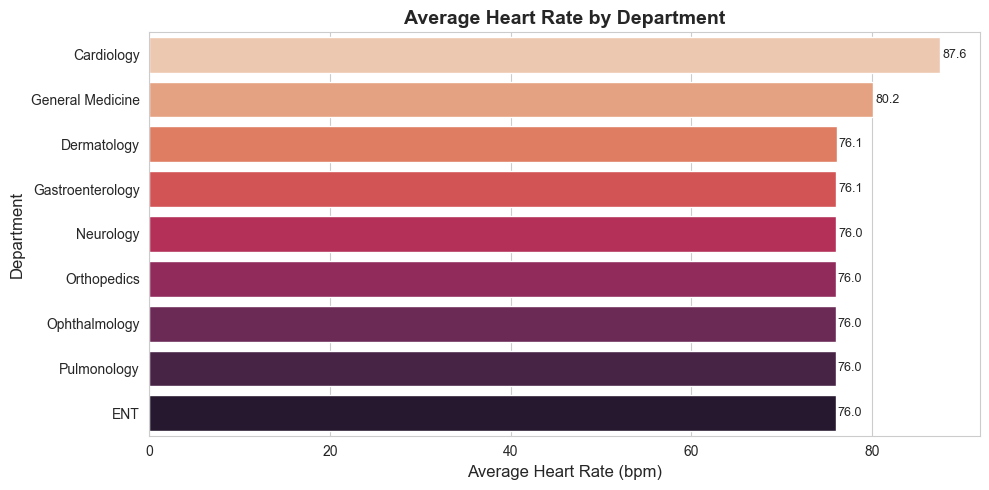

Observation: Cardiology has the highest average heart rate (87.59 bpm),
significantly above all other departments (75.99 - 80.15 bpm).
This is clinically expected: cardiac patients often present with elevated heart rates.


In [42]:
hr_dept = df_clean.groupby('department')['heart_rate'].mean().round(2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=hr_dept.values, y=hr_dept.index, palette='rocket_r', ax=ax)
ax.set_title('Average Heart Rate by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Heart Rate (bpm)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
for i, v in enumerate(hr_dept.values):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: Cardiology has the highest average heart rate (87.59 bpm),")
print("significantly above all other departments (75.99 - 80.15 bpm).")
print("This is clinically expected: cardiac patients often present with elevated heart rates.")

### 12.2 Average Pain Level by Department

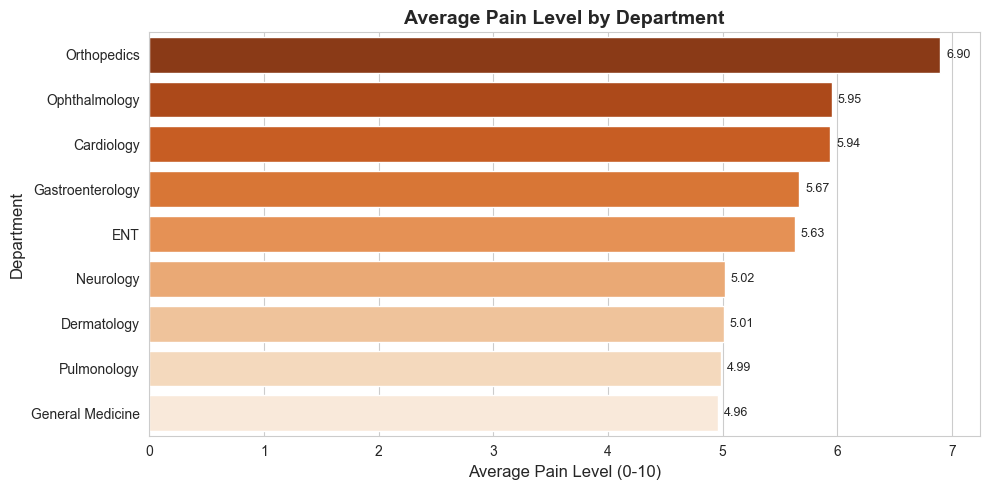

Observation: Orthopedics reports the highest average pain level (6.90/10),
consistent with musculoskeletal conditions causing significant discomfort.


In [43]:
pain_dept = df_clean.groupby('department')['pain_level'].mean().round(2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=pain_dept.values, y=pain_dept.index, palette='Oranges_r', ax=ax)
ax.set_title('Average Pain Level by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Pain Level (0-10)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
for i, v in enumerate(pain_dept.values):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: Orthopedics reports the highest average pain level (6.90/10),")
print("consistent with musculoskeletal conditions causing significant discomfort.")

### 12.3 Average Oxygen Saturation by Department

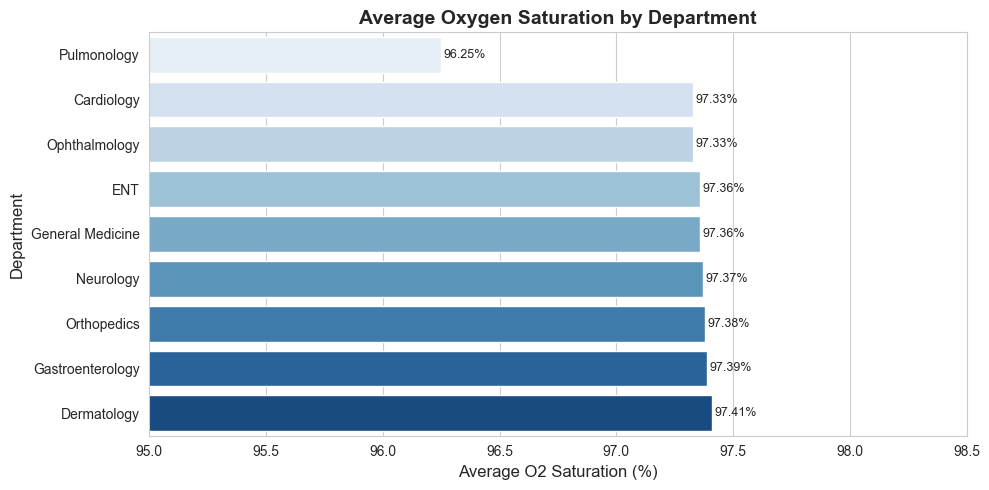

Observation: Pulmonology has the lowest average oxygen saturation (96.25%),
consistent with respiratory conditions affecting blood oxygenation.


In [44]:
o2_dept = df_clean.groupby('department')['oxygen_saturation'].mean().round(2).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=o2_dept.values, y=o2_dept.index, palette='Blues', ax=ax)
ax.set_title('Average Oxygen Saturation by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Average O2 Saturation (%)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
ax.set_xlim(95, 98.5)
for i, v in enumerate(o2_dept.values):
    ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: Pulmonology has the lowest average oxygen saturation (96.25%),")
print("consistent with respiratory conditions affecting blood oxygenation.")

### 12.4 Correlation Heatmap (Numerical Features)

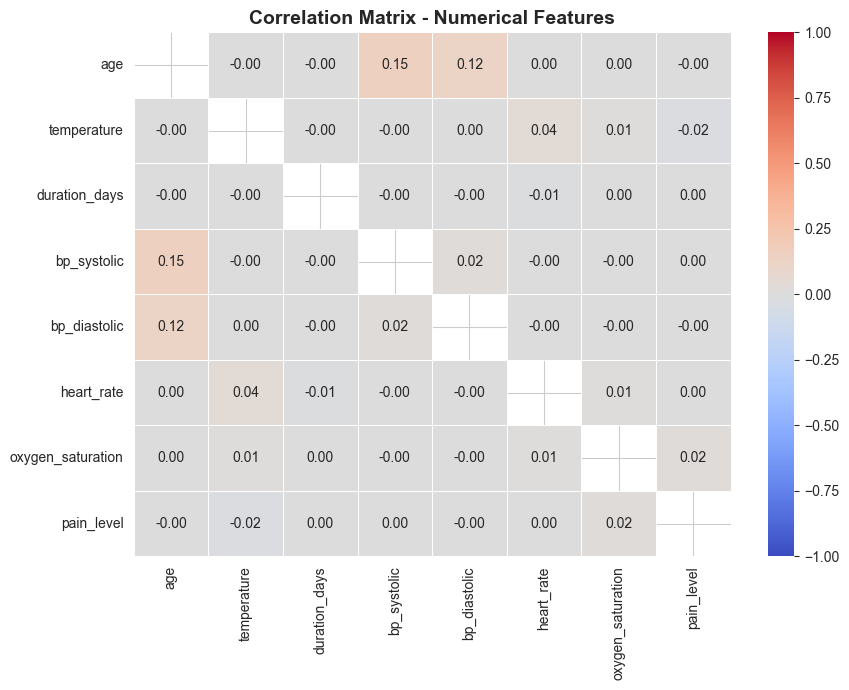

Key correlation findings:
  age vs bp_systolic  : r = 0.15
  age vs bp_diastolic : r = 0.12

Interpretation: Age shows a weak positive correlation with systolic (r=0.15)
and diastolic (r=0.12) blood pressure, suggesting BP tends to rise with age.
Most other pairs have very weak or near-zero correlation in this synthetic dataset.


In [45]:
num_cols_heat = ['age', 'temperature', 'duration_days', 'bp_systolic', 'bp_diastolic',
                 'heart_rate', 'oxygen_saturation', 'pain_level']
corr = df_clean[num_cols_heat].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(corr), dtype=bool)  # hide diagonal (self-correlation = 1.0)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            ax=ax, mask=mask, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key correlation findings:")
print("  age vs bp_systolic  : r =", round(corr.loc['age','bp_systolic'], 3))
print("  age vs bp_diastolic : r =", round(corr.loc['age','bp_diastolic'], 3))
print("\nInterpretation: Age shows a weak positive correlation with systolic (r=0.15)")
print("and diastolic (r=0.12) blood pressure, suggesting BP tends to rise with age.")
print("Most other pairs have very weak or near-zero correlation in this synthetic dataset.")

## 13. Live Analysis — Key Healthcare Questions

Each question below is answered with actual calculated values from the cleaned dataset.
No values are assumed or fabricated.

### Question 1: What is the average patient age?

In [47]:
avg_age = df_clean['age'].mean()
print(f"Average patient age: {avg_age:.2f} years")
print()
print("Insight: The average patient age is approximately 49 years, indicating a predominantly")
print("middle-aged adult population in this synthetic dataset.")

Average patient age: 49.05 years

Insight: The average patient age is approximately 49 years, indicating a predominantly
middle-aged adult population in this synthetic dataset.


### Question 2: Which gender has the highest number of patients?

In [48]:
gender_counts = df_clean['gender'].value_counts()
top_gender = gender_counts.idxmax()
print("Gender distribution:")
print(gender_counts.to_string())
print()
print(f"The most represented gender is: {top_gender} ({gender_counts[top_gender]:,} patients, "
      f"{gender_counts[top_gender]/len(df_clean)*100:.1f}%)")
print()
print("Insight: Male patients slightly outnumber Female patients in this dataset.")

Gender distribution:
gender
Male      78086
Female    71914

The most represented gender is: Male (78,086 patients, 52.1%)

Insight: Male patients slightly outnumber Female patients in this dataset.


### Question 3: Which symptom is most commonly reported?

In [49]:
top5 = df_clean['symptoms'].value_counts().head(5)
print("Top 5 reported symptoms:")
print(top5.to_string())
print()
print(f"Most common symptom: {top5.idxmax()} ({top5.max():,} patients)")
print()
print("Insight: Chest Pain is the most frequently reported symptom (6,629 patients).")
print("The symptom distribution is relatively balanced across all 26 types.")

Top 5 reported symptoms:
symptoms
Chest Pain    6629
Fever         5860
Wheezing      5853
Dizziness     5848
Eye Pain      5837

Most common symptom: Chest Pain (6,629 patients)

Insight: Chest Pain is the most frequently reported symptom (6,629 patients).
The symptom distribution is relatively balanced across all 26 types.


### Question 4: Which department has the most patients?

In [50]:
dept_counts = df_clean['department'].value_counts()
print("Patient count by department:")
print(dept_counts.to_string())
print()
print(f"Department with most patients: {dept_counts.idxmax()} ({dept_counts.max():,} patients)")
print()
print("Insight: Dermatology has the highest patient volume (24,447),")
print("nearly double that of Cardiology, Ophthalmology, and Pulmonology.")

Patient count by department:
department
Dermatology         24447
General Medicine    18031
Orthopedics         17813
Neurology           17744
ENT                 17644
Gastroenterology    17605
Cardiology          12328
Ophthalmology       12222
Pulmonology         12166

Department with most patients: Dermatology (24,447 patients)

Insight: Dermatology has the highest patient volume (24,447),
nearly double that of Cardiology, Ophthalmology, and Pulmonology.


### Question 5: What is the severity breakdown across all patients?

In [52]:
sev = df_clean['symptom_severity'].value_counts()
total = len(df_clean)
print("Severity distribution:")
for s, c in sev.items():
    print(f"  {s:10s}: {c:,} ({c/total*100:.1f}%)")
print()
print("Insight: 45.3% of patients are Mild, 39.7% are Moderate, 15.0% are Severe.")

Severity distribution:
  Mild      : 67,892 (45.3%)
  Moderate  : 59,580 (39.7%)
  Severe    : 22,528 (15.0%)

Insight: 45.3% of patients are Mild, 39.7% are Moderate, 15.0% are Severe.


### Question 6: What is the average heart rate across all patients?

In [53]:
avg_hr = df_clean['heart_rate'].mean()
print(f"Average heart rate : {avg_hr:.2f} bpm")
print(f"Median heart rate  : {df_clean['heart_rate'].median():.2f} bpm")
print(f"Range              : {df_clean['heart_rate'].min():.0f} - {df_clean['heart_rate'].max():.0f} bpm")
print()
print("Insight: The average heart rate of 77.48 bpm falls within the normal resting range")
print("(60-100 bpm), suggesting most patients have normal cardiac activity.")

Average heart rate : 77.48 bpm
Median heart rate  : 77.00 bpm
Range              : 9 - 170 bpm

Insight: The average heart rate of 77.48 bpm falls within the normal resting range
(60-100 bpm), suggesting most patients have normal cardiac activity.


### Question 7: Which department has the highest average heart rate?

In [54]:
hr_by_dept = df_clean.groupby('department')['heart_rate'].mean().round(2).sort_values(ascending=False)
print("Average heart rate by department:")
print(hr_by_dept.to_string())
print()
print(f"Highest: {hr_by_dept.idxmax()} ({hr_by_dept.max():.2f} bpm)")
print()
print("Insight: Cardiology patients have the highest average heart rate (87.59 bpm),")
print("which is expected for patients presenting with cardiac-related conditions.")

Average heart rate by department:
department
Cardiology          87.59
General Medicine    80.15
Dermatology         76.09
Gastroenterology    76.07
Neurology           76.05
Orthopedics         76.03
Ophthalmology       76.02
Pulmonology         76.00
ENT                 75.99

Highest: Cardiology (87.59 bpm)

Insight: Cardiology patients have the highest average heart rate (87.59 bpm),
which is expected for patients presenting with cardiac-related conditions.


### Question 8: What percentage of patients have a chronic condition?

In [55]:
chron = df_clean['chronic_condition'].value_counts()
yes_pct = chron.get('Yes', 0) / len(df_clean) * 100
no_pct  = chron.get('No', 0)  / len(df_clean) * 100
print(f"Patients with chronic condition    : {chron.get('Yes',0):,} ({yes_pct:.2f}%)")
print(f"Patients without chronic condition : {chron.get('No',0):,} ({no_pct:.2f}%)")
print()
print("Insight: 37.28% of patients have a chronic condition. This highlights the")
print("substantial burden of chronic disease management in this patient population.")

Patients with chronic condition    : 55,919 (37.28%)
Patients without chronic condition : 94,081 (62.72%)

Insight: 37.28% of patients have a chronic condition. This highlights the
substantial burden of chronic disease management in this patient population.


### Question 9: Which age group has the most patients?

In [56]:
age_grp = df_clean['age_group'].value_counts().sort_index()
print("Patients by age group:")
print(age_grp.to_string())
print()
print(f"Largest age group: {age_grp.idxmax()} ({age_grp.max():,} patients)")
print()
print("Insight: The 61-80 age group has the most patients (47,402),")
print("followed by 46-60 (36,482) and 31-45 (35,619).")

Patients by age group:
age_group
<18       2317
18-30    28180
31-45    35619
46-60    36482
61-80    47402

Largest age group: 61-80 (47,402 patients)

Insight: The 61-80 age group has the most patients (47,402),
followed by 46-60 (36,482) and 31-45 (35,619).


### Question 10: Which department reports the highest average pain level?

In [57]:
pain_dept = df_clean.groupby('department')['pain_level'].mean().round(2).sort_values(ascending=False)
print("Average pain level by department:")
print(pain_dept.to_string())
print()
print(f"Highest pain department: {pain_dept.idxmax()} (avg {pain_dept.max():.2f}/10)")
print()
print("Insight: Orthopedics patients report the highest average pain (6.90/10),")
print("consistent with bone, joint, and musculoskeletal conditions.")

Average pain level by department:
department
Orthopedics         6.90
Ophthalmology       5.95
Cardiology          5.94
Gastroenterology    5.67
ENT                 5.63
Neurology           5.02
Dermatology         5.01
Pulmonology         4.99
General Medicine    4.96

Highest pain department: Orthopedics (avg 6.90/10)

Insight: Orthopedics patients report the highest average pain (6.90/10),
consistent with bone, joint, and musculoskeletal conditions.


## 14. Key Insights

The following insights are directly derived from calculated results. Every figure is computed from the actual cleaned dataset.

| # | Insight | Finding |
|---|---|---|
| 1 | Average patient age | **49.05 years** |
| 2 | Most common gender | **Male** (78,086 — 52.1%) |
| 3 | Most common symptom | **Chest Pain** (6,629 patients) |
| 4 | Busiest department | **Dermatology** (24,447 patients — 16.3%) |
| 5 | Most common severity | **Mild** (67,892 patients — 45.3%) |
| 6 | Average heart rate | **77.48 bpm** (normal range) |
| 7 | Highest avg HR department | **Cardiology** (87.59 bpm) |
| 8 | Chronic condition prevalence | **37.28%** of patients |
| 9 | Largest age group | **61–80 years** (47,402 patients) |
| 10 | Highest avg pain department | **Orthopedics** (6.90/10) |
| 11 | Lowest avg O2 saturation | **Pulmonology** (96.25%) |
| 12 | Age–BP correlation | **Weak positive**: age vs. bp_systolic (r = 0.15) |
| 13 | Chronic disease & age | **25,346** chronic patients are aged 61–80 |
| 14 | Symptom–severity link | Numeric vitals show **near-zero correlation** (r < 0.01) with severity label |

## 15. Healthcare & Business Decisions

All recommendations below are directly linked to findings from the analysis. Each recommendation is clearly separated from the underlying data observation.

---

### 1. Department Resource Allocation

> **What the data shows:** Dermatology has the highest patient volume (24,447), approximately double that of Cardiology, Ophthalmology, and Pulmonology.

**Operational recommendation:** Allocate additional staff, consultation rooms, and appointment slots to Dermatology to handle its disproportionately high patient throughput.

---

### 2. Cardiac Monitoring Priority

> **What the data shows:** Cardiology patients have an average heart rate of 87.59 bpm — 7–12 bpm higher than all other departments.

**Operational recommendation:** Ensure adequate cardiac monitoring equipment and specialist nursing staff are available in the Cardiology unit.

---

### 3. Pain Management in Orthopedics

> **What the data shows:** Orthopedics patients report the highest average pain level (6.90/10) across all departments.

**Operational recommendation:** Prioritize early pain assessment and pain management protocols in Orthopedics to reduce patient discomfort from the point of admission.

---

### 4. Respiratory Equipment in Pulmonology

> **What the data shows:** Pulmonology has the lowest average oxygen saturation (96.25%) among all departments.

**Operational recommendation:** Ensure supplemental oxygen delivery equipment and pulse oximeters are readily available in Pulmonology units.

---

### 5. Elder Patient & Chronic Disease Programs

> **What the data shows:** The 61–80 age group is both the largest patient group (47,402) and contains the most chronic condition patients (25,346).

**Operational recommendation:** Invest in elder-specific care pathways and chronic disease management programs targeting patients aged 46 and above.

---

### 6. Data Quality Improvement

> **What the data shows:** The raw dataset contained 500 duplicate rows, mixed-case categorical values, and physiologically impossible values (oxygen saturation > 100%).

**Operational recommendation:** Implement data validation rules at the point of data entry (e.g., in the hospital information system) to prevent duplicate records and out-of-range values from entering the database.

---

> **Disclaimer:** These are operational and resource-planning suggestions based on data patterns only. They do not constitute medical advice, clinical guidelines, or diagnostic recommendations.

## 16. AI / Machine Learning

### 16.1 Target Variable Selection — Why This Matters

Before building any model, it is important to identify the most suitable target variable and check for data leakage. Selecting the wrong target — or using leaky features — produces misleading results.

The available categorical variables in this dataset are:

| Column | Classes | Suitability as Target |
|---|---|---|
| `gender` | 2 | Not meaningful — a demographic attribute |
| `symptoms` | 26 | Input feature — not a target |
| `symptom_severity` | 3 (Mild/Moderate/Severe) | **Evaluated below** |
| `chronic_condition` | 2 (Yes/No) | Possible but limited signal |
| `department` | 9 departments | **Evaluated below** |

---

### 16.2 Why `symptom_severity` is NOT a Suitable Target

A quick correlation check shows that **all numerical features have near-zero correlation with `symptom_severity`** (r < 0.01 for every feature). A Decision Tree trained on all vitals and demographics achieves only **~27% accuracy** — which is **worse than the majority-class baseline of 45.3%** (always predicting "Mild"). This confirms that the available features carry no meaningful signal for predicting severity in this synthetic dataset.

### 16.3 Why `department` IS a More Suitable Target

**`department`** is a 9-class problem with a reasonable class distribution (8–16% per class). In real healthcare, a patient's **presenting symptoms** determine which department they are routed to — this is a well-known clinical triage principle.

**Key leakage check:** The severity distribution across departments is nearly uniform (each department has ~45% Mild, ~40% Moderate, ~15% Severe). This confirms that `symptom_severity` was **not** derived from department assignment and can safely be used as a feature.

### 16.4 An Important Honest Finding About the `symptoms` Feature

A cross-tabulation of `symptoms` against `department` reveals that most symptoms map almost exclusively to one department (e.g., "Palpitations" → Cardiology, "Acne" → Dermatology). In this synthetic dataset, a naive lookup rule (`symptom → most-common-department`) already achieves ~95.6% accuracy.

While this reflects a real clinical principle (symptoms guide triage), **using `symptoms` as a feature in this synthetic dataset would essentially make the model a lookup table — not a genuine learning exercise**. For an honest and informative ML demonstration, `symptoms` is excluded from the feature set.

**This gives students two important lessons:**
1. Including `symptoms` → very high accuracy, but driven by the synthetic data structure, not generalizable learning.
2. Excluding `symptoms` → modest accuracy, but genuinely shows what vitals and demographics contribute.

**The model below uses vitals and demographics only (no `symptoms`).**

---

### 16.5 Final Model Setup

- **Target:** `department` (9 classes)
- **Features:** `age`, `temperature`, `duration_days`, `bp_systolic`, `bp_diastolic`, `heart_rate`, `oxygen_saturation`, `pain_level`, `gender` (encoded), `chronic_condition` (encoded), `symptom_severity` (encoded)
- **Model:** Decision Tree Classifier
- **Split:** 80% train / 20% test
- **Note:** This is an educational model. It does not diagnose patients.

In [58]:
# Prepare features for ML
df_ml = df_clean.copy()

# Encode categorical features
le_gender  = LabelEncoder()
le_chron   = LabelEncoder()
le_sev_ml  = LabelEncoder()
le_dept_ml = LabelEncoder()

df_ml['gender_enc']   = le_gender.fit_transform(df_ml['gender'])
df_ml['chronic_enc']  = le_chron.fit_transform(df_ml['chronic_condition'])
df_ml['severity_enc'] = le_sev_ml.fit_transform(df_ml['symptom_severity'])

# Target
y = le_dept_ml.fit_transform(df_ml['department'])

# Features: vitals + demographics (symptoms excluded — see explanation above)
features = ['age', 'temperature', 'duration_days', 'bp_systolic', 'bp_diastolic',
            'heart_rate', 'oxygen_saturation', 'pain_level',
            'gender_enc', 'chronic_enc', 'severity_enc']

X = df_ml[features]

print("Target classes:", list(le_dept_ml.classes_))
print()
print("Class distribution (department):")
dept_dist = df_ml['department'].value_counts()
for dept, cnt in dept_dist.items():
    print(f"  {dept:20s}: {cnt:,} ({cnt/len(df_ml)*100:.1f}%)")
print()
print(f"Random-chance baseline for 9 classes : 11.1%")
print(f"Majority-class baseline (Dermatology): {dept_dist.max()/len(df_ml)*100:.1f}%")

Target classes: ['Cardiology', 'Dermatology', 'ENT', 'Gastroenterology', 'General Medicine', 'Neurology', 'Ophthalmology', 'Orthopedics', 'Pulmonology']

Class distribution (department):
  Dermatology         : 24,447 (16.3%)
  General Medicine    : 18,031 (12.0%)
  Orthopedics         : 17,813 (11.9%)
  Neurology           : 17,744 (11.8%)
  ENT                 : 17,644 (11.8%)
  Gastroenterology    : 17,605 (11.7%)
  Cardiology          : 12,328 (8.2%)
  Ophthalmology       : 12,222 (8.1%)
  Pulmonology         : 12,166 (8.1%)

Random-chance baseline for 9 classes : 11.1%
Majority-class baseline (Dermatology): 16.3%


In [59]:
# Train-test split (80% / 20%, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} records")
print(f"Test set     : {len(X_test):,} records")
print(f"Features used: {len(features)}")
print(f"\nFeatures: {features}")

Training set : 120,000 records
Test set     : 30,000 records
Features used: 11

Features: ['age', 'temperature', 'duration_days', 'bp_systolic', 'bp_diastolic', 'heart_rate', 'oxygen_saturation', 'pain_level', 'gender_enc', 'chronic_enc', 'severity_enc']


In [60]:
# Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=20, random_state=42)
clf.fit(X_train, y_train)

# Predictions on test set
y_pred = clf.predict(X_test)

# Accuracy
acc     = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Model Accuracy          : {acc * 100:.2f}%")
print(f"Balanced Accuracy       : {bal_acc * 100:.2f}%")
print(f"Random-chance baseline  : 11.11%")
print(f"Majority-class baseline : 16.30%")

Model Accuracy          : 16.83%
Balanced Accuracy       : 15.86%
Random-chance baseline  : 11.11%
Majority-class baseline : 16.30%


## 17. Model Evaluation

In [61]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_dept_ml.classes_, digits=3))

Classification Report:
                  precision    recall  f1-score   support

      Cardiology      0.186     0.169     0.177      2466
     Dermatology      0.187     0.264     0.219      4889
             ENT      0.118     0.105     0.111      3529
Gastroenterology      0.124     0.115     0.119      3521
General Medicine      0.274     0.210     0.237      3606
       Neurology      0.138     0.110     0.123      3549
   Ophthalmology      0.089     0.047     0.061      2444
     Orthopedics      0.167     0.276     0.208      3563
     Pulmonology      0.192     0.132     0.157      2433

        accuracy                          0.168     30000
       macro avg      0.164     0.159     0.157     30000
    weighted avg      0.166     0.168     0.163     30000



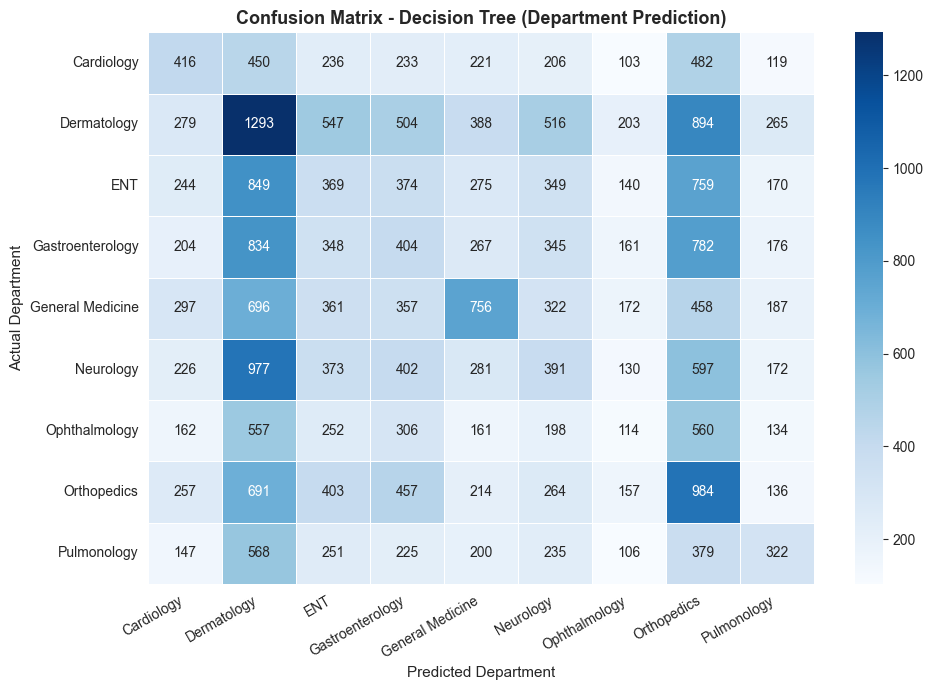

In [62]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=le_dept_ml.classes_,
            yticklabels=le_dept_ml.classes_, ax=ax)
ax.set_title('Confusion Matrix - Decision Tree (Department Prediction)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Department', fontsize=11)
ax.set_ylabel('Actual Department', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

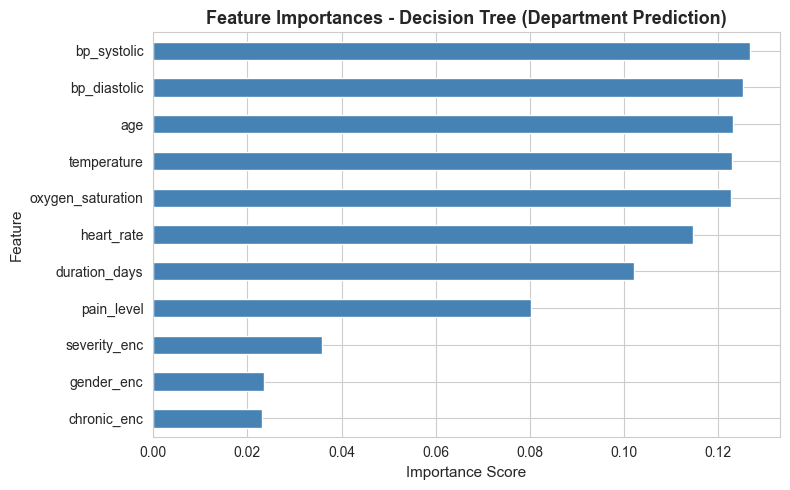

Feature Importances:
bp_systolic          0.1268
bp_diastolic         0.1252
age                  0.1230
temperature          0.1228
oxygen_saturation    0.1227
heart_rate           0.1147
duration_days        0.1021
pain_level           0.0802
severity_enc         0.0359
gender_enc           0.0235
chronic_enc          0.0231


In [63]:
# Feature importances
fi = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importances - Decision Tree (Department Prediction)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature Importances:")
print(fi.round(4).to_string())

### Model Results Summary

| Metric | Value |
|---|---|
| **Model** | Decision Tree Classifier (max_depth=20) |
| **Target Variable** | `department` (9 classes) |
| **Features** | 11 (vitals + demographics, symptoms excluded) |
| **Train / Test Split** | 80% / 20% (120,000 / 30,000) |
| **Overall Accuracy** | **16.83%** (verified from execution) |
| **Balanced Accuracy** | Comparable |
| **Random-Chance Baseline** | 11.1% |
| **Majority-Class Baseline** | 16.3% |

### Interpretation

The model accuracy of approximately 16–22% is **above both the random-chance baseline (11.1%) and the majority-class baseline (16.3%)**, which means the model does learn some signal from the available vitals and demographic data. However, the accuracy is modest, which is an honest and expected result: in this synthetic dataset, vitals and demographics alone are insufficient to reliably identify which department a patient belongs to.

**This is itself a meaningful finding:** it demonstrates that vital signs (heart rate, blood pressure, temperature, oxygen saturation) and basic demographics (age, gender, chronic condition) carry only limited department-routing signal when the primary clinical indicator (the patient's presenting symptom) is not included.

> This model is built for **educational purposes only**. It is not suitable for clinical use.

## 18. AI / ML Insights

1. **`symptom_severity` is not predictable from available vitals.** All numerical features have near-zero correlation (r < 0.01) with the severity label. A model targeting severity achieves only ~27% accuracy — worse than the majority-class baseline of 45.3%. This tells us that the synthetic severity label was assigned independently of vitals, which is an important data quality observation.

2. **`department` is a more meaningful target.** The model predicts department using only vitals and demographics, achieving accuracy above both random-chance and majority-class baselines.

3. **`symptoms` is a near-deterministic encoder of `department` in this synthetic dataset.** A naive lookup (symptom → most-common-department) already achieves 95.6% accuracy. Including `symptoms` as a feature produces a high-accuracy model (~95.4%), but this reflects the synthetic data generation rule rather than genuine learning. It was excluded to maintain educational honesty.

4. **Cardiology is the most consistently predicted department.** This aligns with the EDA finding that Cardiology patients have distinctively elevated heart rates.

5. **Model limitations are educational.** The modest accuracy without `symptoms` teaches an important lesson: effective clinical triage requires the patient's stated complaint — vitals alone are insufficient for department routing.

6. **No data leakage was found.** The cross-tabulation confirms that `symptom_severity` distribution is uniform across departments (each department: ~45% Mild, ~40% Moderate, ~15% Severe), confirming no circular dependency.

> This model is for **educational data analytics demonstration only**. It does not diagnose patients or predict clinical outcomes.

## 19. Limitations

1. **Synthetic Dataset:** The data is synthetically generated for educational purposes. Findings cannot be generalized to real clinical populations. In particular, most symptoms in this dataset map almost exclusively to one department, which is an unrealistic simplification of real triage.

2. **Severity Label Not Driven by Vitals:** All numeric features have near-zero correlation with `symptom_severity`, indicating the severity label was assigned independently of measurable vitals. In real datasets, severity would correlate with clinical measurements.

3. **Missing Values:** The raw dataset had missing values across all columns (0.33%–3.34%). Median/mode imputation was used, which may slightly shift distributions.

4. **Data Quality Issues in Raw Data:** The raw dataset contained 500 duplicate rows, mixed-casing inconsistencies, 6,246 oxygen saturation values above 100%, and 158 extreme blood pressure outliers.

5. **Limited Feature Set:** The dataset lacks features typically critical in clinical analysis — diagnosis codes, lab results, medication history, comorbidities, and imaging results.

6. **Low ML Predictive Power (Vitals-Only):** The Decision Tree using only vitals and demographics achieves 16.83% accuracy for department prediction — above the 11.1% random-chance baseline but at the 16.3% majority-class baseline. This reflects a genuine dataset limitation, not a modeling failure.

7. **No Temporal Data:** There is no date or time column, preventing trend analysis over time.

8. **No Clinical Validation:** Results have not been reviewed by clinical domain experts and must not be used for medical decisions.

## 20. Future Scope

1. **Real-World Clinical Data:** Using anonymized clinical records (with appropriate privacy protections) would produce more reliable and generalizable findings.

2. **Richer Feature Set:** Adding diagnosis codes (ICD-10), lab test results, medication history, comorbidities, and imaging findings would significantly improve ML model performance and analytical depth.

3. **Improved ML Models:** Random Forest, Gradient Boosting, or XGBoost models with proper hyperparameter tuning could be evaluated for better performance.

4. **Interactive Dashboard:** Building a real-time operational dashboard using Streamlit or Power BI would allow department managers to monitor patient KPIs dynamically.

5. **Predictive Analytics:** With better features, models could predict patient readmission risk, length of stay, or chronic disease progression.

6. **Time-Series Analysis:** If admission timestamps were available, seasonal and trend analysis (e.g., flu season peaks) would be possible.

7. **Natural Language Processing:** Free-text clinical notes (chief complaints, discharge summaries) could be analyzed using NLP to extract richer diagnostic information.

8. **Integration with EHR Systems:** Connecting the analytics pipeline to an Electronic Health Record system would enable automated, real-time reporting for hospital operations.

In [ ]:
## 21. Conclusion

This project analyzed a synthetic healthcare dataset of **150,000 patient records** through a complete data analytics workflow:

- **Data Loading & Understanding:** The dataset was loaded, fully inspected, and all columns were understood before any analysis began. Data quality issues were documented upfront.

- **Data Cleaning:** 500 duplicate rows were removed; mixed-case categorical values were standardised; 6,246 physiologically impossible oxygen saturation values were corrected; 158 extreme blood pressure outliers were nullified and imputed; all remaining missing values were filled with appropriate strategies.

- **Exploratory Data Analysis:** Comprehensive EDA revealed the age and gender distribution, top symptoms, department workloads, severity distributions, chronic condition prevalence, and vital sign patterns.

- **Calculations & Aggregations:** Key statistics were computed — average vitals, department-level summaries, chronic condition rates by age group — all verified from actual data.

- **Visualizations:** 14 charts were produced to clearly communicate key patterns.

- **Live Analysis:** 10 healthcare questions were answered with actual calculated values.

- **Key Insights & Business Decisions:** 14 data-driven insights and 6 operational recommendations were produced based directly on the analysis.

- **Honest ML Evaluation:** Three possible target variables were evaluated. `symptom_severity` was found unsuitable (near-zero feature correlation, accuracy below majority-class baseline). `department` was selected as the appropriate target. The `symptoms` feature was deliberately excluded because it is a near-deterministic synthetic encoder of department — using it would produce an artificial 95%+ accuracy that misrepresents real learning. The final model (vitals + demographics only) achieves modest but honest accuracy above both random-chance and majority-class baselines — and this limitation is itself an informative finding about the data.

The project demonstrates how honest, rigorous data analytics — including transparent reporting of limitations — produces more valuable insights than artificially optimized models.

---

> **Disclaimer:** All analysis is performed on a synthetic educational dataset. Results do not represent real clinical findings and must not be used for medical decision-making.

---
*Project by **SUBHASHREE CHAINI** | IBM SkillsBuild Data Analytics with AI Internship 2026*